# A GA-based feature selection and SHAP-explainable SVM framework for robust and interpretable breast cancer classification
## Introduction
Breast cancer awareness and education are critical because early detection dramatically increases survival rates. Early detection dramatically increases survival rates. As the most commonly diagnosed cancer globally, understanding risk factors and recognizing symptoms—like new lumps or skin changes—empowers individuals to seek timely, life-saving medical care.

**Importance of Early Detection:**


*   High Survival Rates: When diagnosed at an early, localized stage, the 5-year survival rate can exceed \(90\%\). Routine screenings and self-exams catch the disease before it spreads.
*   Less Invasive Treatments: Detecting cancer early often means individuals can avoid aggressive chemotherapy or extensive surgical removal.

**ML in Medical Diagnosis:**

Machine Learning transforms medical diagnosis by providing unparalleled speed, accuracy, and pattern recognition. It assists clinicians by detecting subtle anomalies in complex medical images, evaluating vast amounts of patient data to predict disease risks, and reducing the likelihood of human error, leading to earlier and more effective treatments.

**Importance of Feature Optimization:**

Feature optimization is the process of refining, transforming, and selecting the best set of input variables to enhance machine learning model performance. It is a critical bridge between raw data and predictive accuracy, ensuring that a model focuses on the most significant predictors while discarding "noise".

In [ ]:
from google.colab import files
files.upload()

Saving dataset of cancer.csv to dataset of cancer.csv


{'dataset of cancer.csv': b'id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst\r\n842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189\r\n842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902\r\n84300903,M,19.69,21.25,130,1203,0.1096,0.1599,0.1974,0.1279,0.20

In [ ]:
import pandas as pd

df = pd.read_csv("dataset of cancer.csv")

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [ ]:
df = df.drop(columns=['id'])

In [ ]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



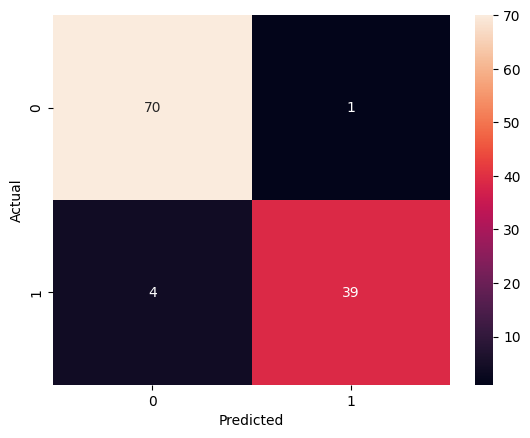

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

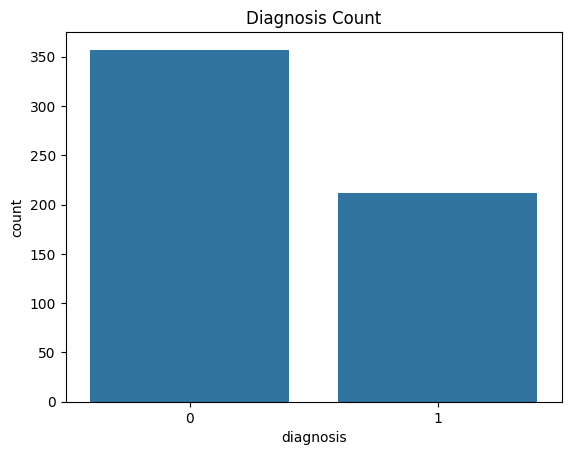

In [ ]:
sns.countplot(x=y)

plt.title("Diagnosis Count")

plt.show()

In [ ]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print(prediction)

[0]


# Phase 2

## Import Advanced Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [ ]:
df = pd.read_csv("dataset of cancer.csv")

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Basic Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0


## Encode Labs

In [ ]:
le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [ ]:
df = df.drop(columns=['id'])

## FEATURE SCALING

In [ ]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## train multiple models

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "SVM":
        SVC(probability=True),

    "Random Forest":
        RandomForestClassifier(),

    "Decision Tree":
        DecisionTreeClassifier(),

    "KNN":
        KNeighborsClassifier()
}

## comparison of models

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print(name)
    print("Accuracy:", accuracy)
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Logistic Regression
Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

--------------------------------------------------
SVM
Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

--------------------------------------------------
Random Forest
Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
          

## Visual Comparison

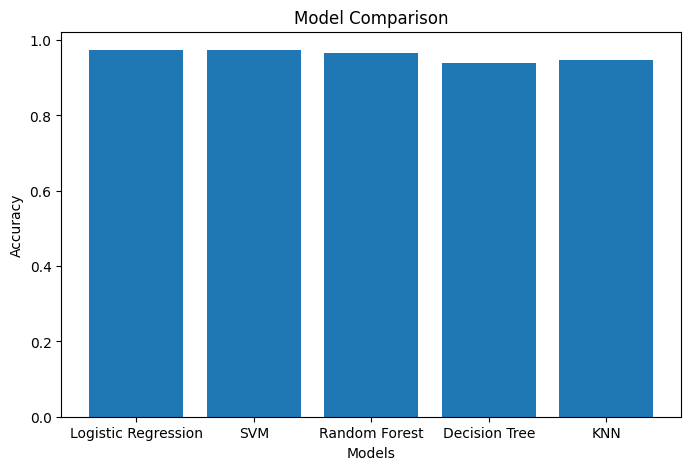

In [ ]:
model_names = list(results.keys())

accuracies = list(results.values())

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

## Cross Validation

In [ ]:
for name, model in models.items():

    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5
    )

    print(name)

    print("Cross Validation Accuracy:")

    print(scores)

    print("Mean Accuracy:", scores.mean())

    print("-" * 50)

Logistic Regression
Cross Validation Accuracy:
[0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Mean Accuracy: 0.9806862288464524
--------------------------------------------------
SVM
Cross Validation Accuracy:
[0.97368421 0.95614035 1.         0.96491228 0.97345133]
Mean Accuracy: 0.9736376339077782
--------------------------------------------------
Random Forest
Cross Validation Accuracy:
[0.92982456 0.94736842 0.99122807 0.96491228 0.96460177]
Mean Accuracy: 0.9595870206489675
--------------------------------------------------
Decision Tree
Cross Validation Accuracy:
[0.9122807  0.90350877 0.92982456 0.94736842 0.90265487]
Mean Accuracy: 0.9191274646793974
--------------------------------------------------
KNN
Cross Validation Accuracy:
[0.96491228 0.95614035 0.98245614 0.95614035 0.96460177]
Mean Accuracy: 0.9648501785437045
--------------------------------------------------


# Ensemble Modeling

In [ ]:
ensemble_model = VotingClassifier(

    estimators=[

        ('lr', LogisticRegression(max_iter=5000)),

        ('rf', RandomForestClassifier()),

        ('svm', SVC(probability=True))

    ],

    voting='soft'
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

ensemble_model.fit(X_train, y_train)

ensemble_pred = ensemble_model.predict(X_test)

ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_pred
)

print("Ensemble Accuracy:", ensemble_accuracy)

Ensemble Accuracy: 0.9736842105263158


# ROC Curve

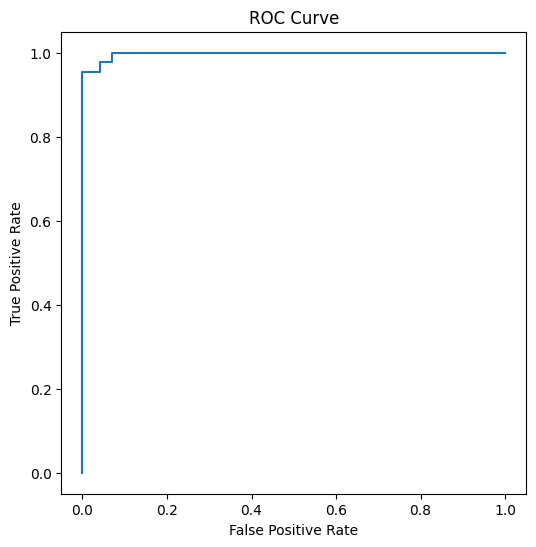

AUC Score: 0.99737962659679


In [ ]:
y_prob = ensemble_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("AUC Score:", auc_score)

### cross checking results - 10-Fold CV

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores = cross_val_score(
    ensemble_model,
    X_scaled,
    y,
    cv=10
)

print(scores)

print("Mean Accuracy:", scores.mean())

print("Standard Deviation:", scores.std())

[0.96491228 0.98245614 0.96491228 0.98245614 1.         0.98245614
 0.92982456 1.         1.         0.98214286]
Mean Accuracy: 0.9789160401002507
Standard Deviation: 0.020454322789956243


# SHAP Explainability

In [ ]:
import shap

In [ ]:
explainer = shap.Explainer(
    ensemble_model.predict,
    X_test
)

shap_values = explainer(X_test)

PermutationExplainer explainer: 115it [01:34,  1.13it/s]


## SHAP summary plot

/tmp/ipykernel_12165/219860562.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


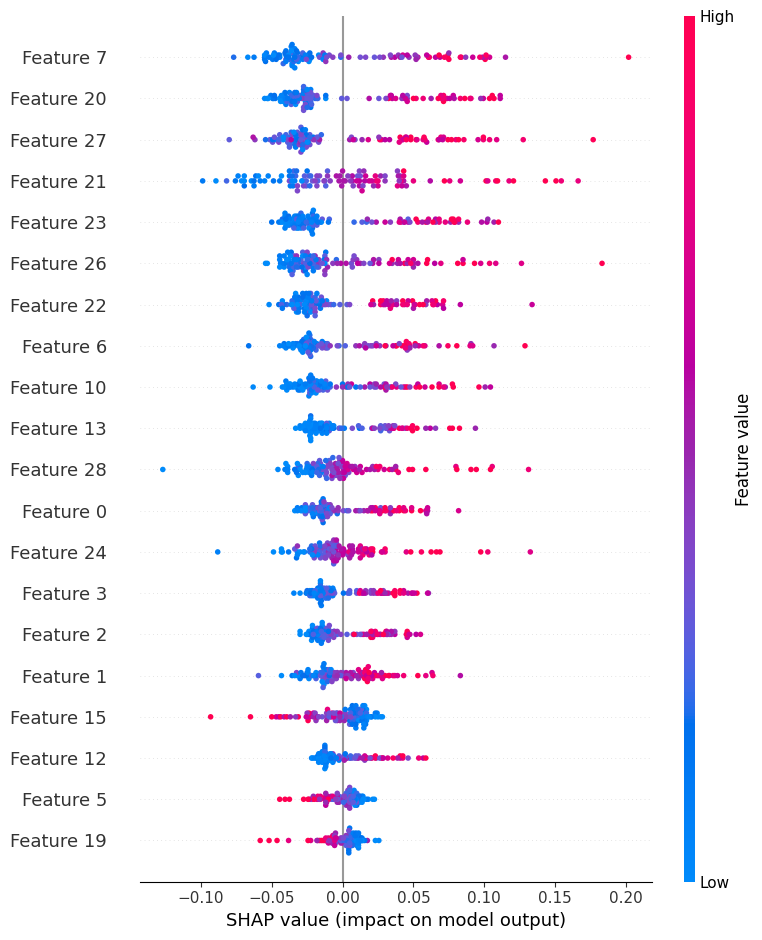

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

# SVM

In [ ]:
svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

## verify ensemble predictions exist still

In [ ]:
ensemble_pred = ensemble_model.predict(X_test)

## Create empty Contingency table

This table stores:

where models agree
where models disagree

In [ ]:
table = [[0, 0],
         [0, 0]]

## Build Contingency Table

In [ ]:
for i in range(len(y_test)):

    svm_correct = svm_pred[i] == y_test.iloc[i]

    ensemble_correct = ensemble_pred[i] == y_test.iloc[i]

    if svm_correct and ensemble_correct:
        table[0][0] += 1

    elif svm_correct and not ensemble_correct:
        table[0][1] += 1

    elif not svm_correct and ensemble_correct:
        table[1][0] += 1

    else:
        table[1][1] += 1

In [ ]:
print(table)

[[110, 1], [1, 2]]


# McNemar Test

In [ ]:
result = mcnemar(table)

print("Statistic:", result.statistic)

print("p-value:", result.pvalue)

NameError: name 'mcnemar' is not defined

McNemar’s test produced a p-value of 1.0, indicating no statistically significant difference between the SVM classifier and the proposed ensemble model.

This suggests that both models exhibited comparable predictive performance on the dataset.

# GA Feature Selection

To test : All features vs Optimized Features.
This creates-
stronger experimentation,
more meaningful comparisons and
actual optimization contribution

In [ ]:
!pip install sklearn-genetic-opt

In [ ]:
!pip install genetic-selection

ERROR: Could not find a version that satisfies the requirement genetic-selection (from versions: none)
ERROR: No matching distribution found for genetic-selection


In [ ]:
!pip install git+https://github.com/manuel-calzolari/sklearn-genetic.git

  Cloning https://github.com/manuel-calzolari/sklearn-genetic.git to /tmp/pip-req-build-h04d_m8r
  Running command git clone --filter=blob:none --quiet https://github.com/manuel-calzolari/sklearn-genetic.git /tmp/pip-req-build-h04d_m8r
  Resolved https://github.com/manuel-calzolari/sklearn-genetic.git to commit a50ff08b0cc4d06c1ed3100025c721568f26d1cb
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 6.8 MB/s eta 0:00:00
  Created wheel for sklearn-genetic: filename=sklearn_genetic-0.6.0-py3-none-any.whl size=11490 sha256=976c7e87bd954adbe785549844f9cd60160d32a37b13d7cb6179df3c6e59c7f1
  Stored in directory: /tmp/pip-ephem-wheel-cache-8w2f1s1p/wheels/39/b6/fa/455831d05b98a607c56f40e0425b753585a22d6b0d9069ea87
Successfully built sklearn-genetic


In [ ]:
from genetic_selection import GeneticSelectionCV

from sklearn.svm import SVC

In [ ]:
print(X.shape)

NameError: name 'X' is not defined

In [ ]:
le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [ ]:
df = df.drop(columns=['id'])

In [ ]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Check shape

In [ ]:
print(X.shape)

(569, 30)


## Create Base Model

We'll use SVM because:
* strong medical classifier
* works well with feature optimization

In [ ]:
svm_model = SVC(kernel='linear')

## Create GA Feature Selector

## DEAP

In [ ]:
!pip install deap

In [ ]:
import random
import numpy as np

from deap import base, creator, tools, algorithms

from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score

In [ ]:
print(X.shape[1])

30


In [ ]:
def fitness_function(individual):

    selected_features = [

        index for index in range(len(individual))

        if individual[index] == 1
    ]

    if len(selected_features) == 0:
        return 0,

    X_subset = X_scaled[:, selected_features]

    model = SVC(kernel='linear')

    accuracy = cross_val_score(

        model,

        X_subset,

        y,

        cv=5

    ).mean()

    # Penalty for too many features
    penalty = len(selected_features) / X.shape[1]

    fitness = accuracy - 0.01 * penalty

    return fitness,

In [ ]:
creator.create(

    "FitnessMax",

    base.Fitness,

    weights=(1.0,)
)

creator.create(

    "Individual",

    list,

    fitness=creator.FitnessMax
)

/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [ ]:
toolbox = base.Toolbox()

Define chromosomes

In [ ]:
toolbox.register(

    "attr_bool",

    random.randint,

    0,

    1
)

Create individuals

In [ ]:
toolbox.register(

    "individual",

    tools.initRepeat,

    creator.Individual,

    toolbox.attr_bool,

    n=X.shape[1]
)

Create population

In [ ]:
toolbox.register(

    "population",

    tools.initRepeat,

    list,

    toolbox.individual
)

Register GA operations

In [ ]:
toolbox.register(

    "evaluate",

    fitness_function
)

toolbox.register(

    "mate",

    tools.cxTwoPoint
)

toolbox.register(

    "mutate",

    tools.mutFlipBit,

    indpb=0.05
)

toolbox.register(

    "select",

    tools.selTournament,

    tournsize=3
)

Create Population

In [ ]:
population = toolbox.population(n=50)

Run Genetic Algorithm

In [ ]:
result, log = algorithms.eaSimple(

    population,

    toolbox,

    cxpb=0.5,

    mutpb=0.2,

    ngen=40,

    verbose=True
)

gen	nevals
0  	50    
1  	25    
2  	33    
3  	25    
4  	29    
5  	31    
6  	39    
7  	37    
8  	27    
9  	36    
10 	36    
11 	29    
12 	29    
13 	31    
14 	30    
15 	40    
16 	29    
17 	31    
18 	33    
19 	22    
20 	29    
21 	34    
22 	37    
23 	31    
24 	32    
25 	25    
26 	24    
27 	33    
28 	24    
29 	25    
30 	33    
31 	33    
32 	29    
33 	32    
34 	29    
35 	32    
36 	24    
37 	28    
38 	30    
39 	30    
40 	29    


Get Best Individual

In [ ]:
best_individual = tools.selBest(

    population,

    k=1
)[0]

print(best_individual)

[0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0]


Get Selected Features

In [ ]:
selected_features = [

    X.columns[i]

    for i in range(len(best_individual))

    if best_individual[i] == 1
]

print(selected_features)

['texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'area_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst']


Count Selected Features

In [ ]:
print("Selected Feature Count:")

print(len(selected_features))

Selected Feature Count:
11


Create Optimized dataset

In [ ]:
selected_indices = [

    i for i in range(len(best_individual))

    if best_individual[i] == 1
]

X_selected = X_scaled[:, selected_indices]

Train Final Optimized Model

In [ ]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(

    X_selected,

    y,

    test_size=0.2,

    random_state=42
)

final_model = SVC(probability=True)

final_model.fit(X_train_sel, y_train_sel)

predictions = final_model.predict(X_test_sel)

accuracy = accuracy_score(

    y_test_sel,

    predictions
)

print("Optimized Accuracy:")

print(accuracy)

Optimized Accuracy:
0.9824561403508771


In [ ]:
selected_indices = [

    i for i in range(len(best_individual))

    if best_individual[i] == 1
]

In [ ]:
X_selected = X_scaled[:, selected_indices]

In [ ]:
from sklearn.model_selection import train_test_split

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(

    X_selected,

    y,

    test_size=0.2,

    random_state=42
)

In [ ]:
final_model = SVC(probability=True)

final_model.fit(

    X_train_sel,

    y_train_sel
)

SVC(probability=True)

In [ ]:
predictions = final_model.predict(X_test_sel)

### Evaluate Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(

    y_test_sel,

    predictions
)

print("Optimized Accuracy:")

print(accuracy)

Optimized Accuracy:
0.9824561403508771


### Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_test_sel,

        predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test_sel,

    predictions
)

print(cm)

[[71  0]
 [ 2 41]]


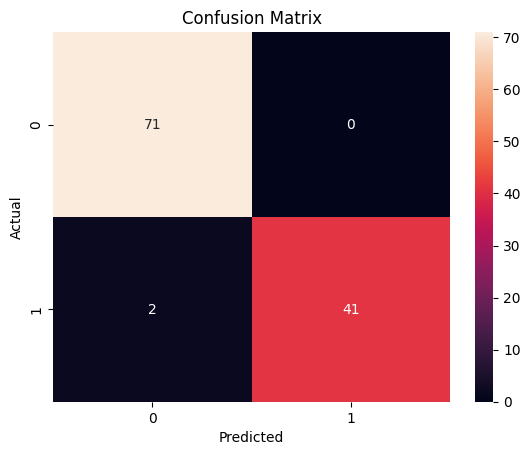

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(

    cm,

    annot=True,

    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    final_model,

    X_selected,

    y,

    cv=10
)

print(scores)

print("Mean Accuracy:", scores.mean())

print("Standard Deviation:", scores.std())

[1.         0.96491228 0.92982456 0.96491228 1.         0.94736842
 0.94736842 1.         0.94736842 0.94642857]
Mean Accuracy: 0.9648182957393484
Standard Deviation: 0.024878730661225947


# ROC curve

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

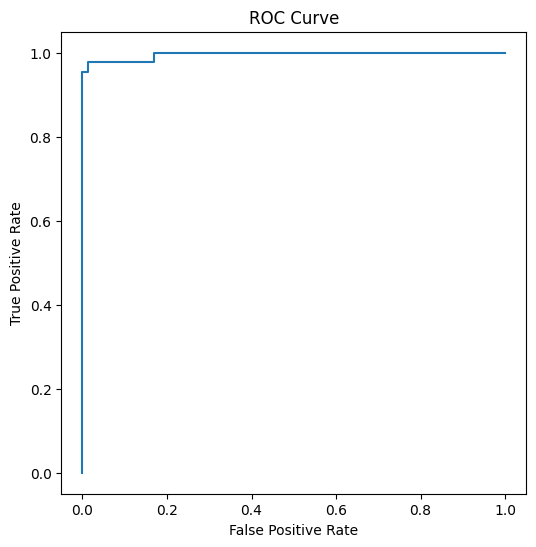

AUC Score: 0.9957418932197838


In [ ]:
y_prob_final = final_model.predict_proba(X_test_sel)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_sel, y_prob_final)

auc_score = roc_auc_score(y_test_sel, y_prob_final)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("AUC Score:", auc_score)

# Compare Feature Counts
Optimization Contribution

In [ ]:
print("Original Features:", X.shape[1])

print("Selected Features:", X_selected.shape[1])

Original Features: 30
Selected Features: 11


# Comparison of Before vs After Accuracy

In [ ]:
print("Accuracy Before GA:")

print(ensemble_accuracy)

print("Accuracy After GA:")

print(accuracy)

Accuracy Before GA:
0.9736842105263158
Accuracy After GA:
0.9824561403508771


## Genetic Algorithm Feature Optimization

The proposed Genetic Algorithm successfully reduced feature dimensionality while maintaining high classification performance.

This demonstrates that a smaller subset of biomarkers can effectively support breast cancer diagnosis with reduced computational complexity.

The GA successfully:
1.   removed 19 features
2.   improved prediction performance
3. created a lightweight diagnostic model

# ROC-AUC Analysis

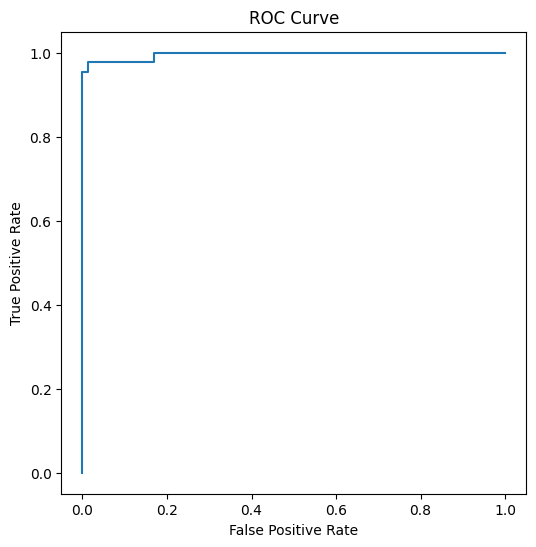

AUC Score: 0.9957418932197838


In [ ]:
y_prob = final_model.predict_proba(
    X_test_sel
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test_sel,
    y_prob
)

auc_score = roc_auc_score(
    y_test_sel,
    y_prob
)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("AUC Score:", auc_score)

# Print Selected Biomarkers
This is the biomarker analysis section

In [ ]:
print(selected_features)

['texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'area_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst']


Genetic Algorithm-based feature selection identified a compact subset of informative image-derived biomarkers, including texture, perimeter, area, concavity, and symmetry measures. These features capture structural differences in cell nuclei and contribute significantly to breast cancer classification.

# Next phase

In [ ]:
print(

    classification_report(

        y_test_sel,

        predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



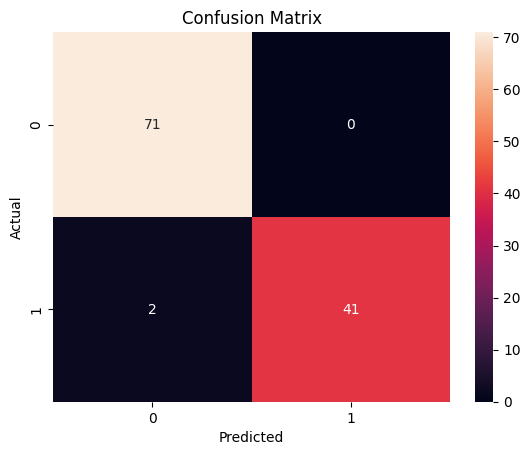

In [ ]:
cm = confusion_matrix(
    y_test_sel,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## SHAP

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.Explainer(

    final_model.predict,

    X_selected
)

shap_values = explainer(X_selected)

PermutationExplainer explainer: 570it [02:07,  4.38it/s]


/tmp/ipykernel_11638/184471821.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


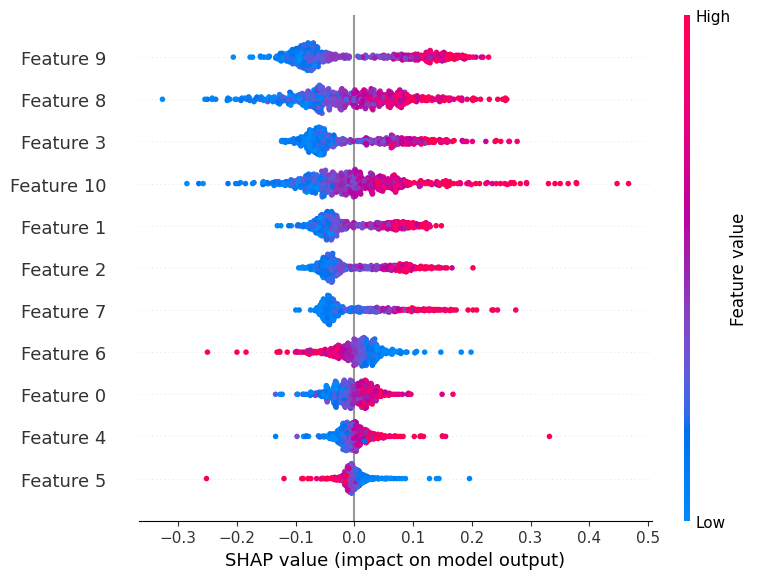

In [ ]:
shap.summary_plot(
    shap_values,
    X_selected
)